## 11. Intepolação polinomial e fórmula de Lagrange

A interpolação polinomial é um método de aproximação de funções por polinômios. A interpolação é utilizada quando se conhece apenas alguns pontos da função ou quando a função é muito complicada e difícil de manejar. Os polinômios têm a vantagem de serem fáceis de derivar e integrar. Além disso, é possível provar que qualquer função contínua pode ser arbitrariamente aproximada por um polinômio (teorema de Weierstrass). 

Outra particularidade é que o valor numérico de um polinômio 

$$P_n(x)= a_0 + a_1x + a_2x^2+...+a_nx^n$$ 

para algum valor real de $x$ pode ser calculado com um número reduzido de operações aritméticas escrevendo-o na forma

$$P_n(x)=a_0+x(a_1+x(a_2+x(...+x(a_{n-1}+xa_n)...)))$$

o que apresenta algumas vantagens computacionalmente, como veremos mais para frente ao realizar a interpolação pela fórmula de Newton.

Interpolar uma função $f(x) = y$ em um conjunto de $n+1$ pontos distintos ${x_0,x_1,...,x_n}$ de um intervalo $[a,b]$ por um polinômio de significa encontrar $P_n(x)= a_0 + a_1x+...+ax^n$ tal que $P(x_i)=y_i$ com  $i = 0,1,...,n$. Ou seja, significa encontrar o polinômio de grau $n$ que "passa" por  esses pontos. 

Na figura abaixo é mostrada um polinômio que interpola uma função a partir de 6 pontos. É possível observar que o polinômio passa pelos pontos, ou seja, $P(x_i) = y_i$, $i=0,1,...,5$, e que aproxima a função razoavelmente bem a função no intervalo de $x_1$ até $x_5$. No intervalo entre $x_0$ e $x_1$ a aproximação não é tão boa e fora do intervalo $(x_0,x_5)$ parece não funcionar muito bem.   

<img src="https://raw.githubusercontent.com/tiagoburiol/MatComp_I/refs/heads/main/11_interpolacao_polinomial_formula_de_lagrange/figuras/figura_3.1.png" width="480">



O caso mais simples de interpolação que podemos analisar é o de encontrar a reta (polinômio de grau 1) que passa por dois pontos, $(x_0, y_0)$ e $(x_1,y_1)$. Nesse caso, o polinômio tem a forma $P(x)=a_0+a_1x$ e para determiná-lo basta encontrar os coeficientes $a_0$ e $a_1$ da única reta que passa por esses dois pontos. Logo, os coeficientes podem ser obtidos resolvendo o sistema linear:

$\begin{cases} 
       y_0 = a_0 + a_1 x_0\\ 
       y_1 = a_0 + a_1 x_1\\
\end{cases}$
ou, na forma matricial
$\left[\begin{array}{cc} 
          1 & x_0 \\ 
	      1 & x_1 \\ 
\end{array} \right]
\left[\begin{array}{c} 
          a_0 \\ 
	      a_1 \\ 
\end{array} \right]=
\left[\begin{array}{c} 
          y_0 \\ 
	      y_1 \\ 
\end{array} \right]$


A solução pode ser obtida fazendo $a_1 = \frac{y_1 - y_0}{x_1 - x_0}$ e $a_0 = y_0 - a_1x_0$.




**Exemplo 11.1:**
Vamos obter o polinômio que interpola os pontos ${(1,2),(5,1)}$.<br>
_Solução:_
Para isso, resolvemos o sistema linear
$$ \begin{cases} 
	         a_0 + a_1 = 2\\ 
	         a_0 + 5a_1 = 1\\
	         \end{cases} $$
que nos fornece:

$a_1=\frac{y_1 - y_0}{x_1 - x_0}=\frac{1 - 2}{5 - 1}=-\frac{1}{4}$
e
$a_0 = y_0 - a_1x_0 = 2 +\frac{1}{4} = \frac{9}{4}$ 

Assim, obtemos

$$P(x)= \frac{9}{4}-\frac{1}{4}x$$

A figura abaixo mostra o resultado

<img src="https://raw.githubusercontent.com/tiagoburiol/MatComp_I/refs/heads/main/11_interpolacao_polinomial_formula_de_lagrange/figuras/figura_3.2.png" width="400">

Assim, generalizando o caso anterior, para obter os coeficientes do polinômio $P(x)=a_0 + a_1x + a_2x^2+...+a_nx^n$, de grau $n$, que interpola uma função a partir de $n+1$ pontos $(x_i,y_i)$, $i=0,1,...,n$, podemos resolver o seguinte sistema 

$\left[\begin{array}{ccccc} 
          1 & x_0 & x_0^2 & ... & x_0^n\\ 
	      1 & x_1 & x_1^2 & ... & x_1^n\\ 
          ...& ... & ... & ... & ...\\ 
          1 & x_n & x_n^2 & ... & x_n^n\\ 
\end{array} \right]
\left[\begin{array}{c} 
          a_0 \\ 
	      a_1 \\ 
          ...\\
          a_n \\ 
\end{array} \right]=
\left[\begin{array}{c} 
          y_0 \\ 
	      y_1 \\ 
          ...\\
          y_n \\
\end{array} \right]$


A matriz $n \times n$ mostrada acima é chamada matriz de Vandermonde e tem determinante não nulo para pontos $x_i$ distintos, ou seja, polinômio de coeficientes $a_0,a_1,...,a_n$ existe e é único. Usando o módulo `polynomial` de Numpy a matriz de Vandermonde pode ser obtida usando a função `np.polynomial.polynomial.polyvander`.

**Exemplo 11.2:**
Considere o problema de encontrar um polinômio interpolador para do conjunto de pontos $\{(0, 1)$, $(1, 6)$, $(2, 5)$, $(3, -8)\}$. Como o conjunto consiste de 4 pontos, o polinômio interpolador deve ser da forma: $p(x) = a_0 + a_1x + a_2x^2 + a_3x^3$

O que nos leva ao sistema linear:

$$\begin{cases} 
    a_0=1\\
    a_0+a_1+a_2+a_3=6\\
    a_0+2a_1+4a_2+ 8a_3=5\\
    a_0+3a_1+9a_2+27a_3=-8
\end{cases} $$

cuja solução é $a_0=1$, $a_1=6$, $a_2=0$ e $a_3=-1$. Portanto, o polinômio interpolador é $p(x)=1+6x-x^3$.

Podemos verificar o resultado plotando os pontos e o polinômio:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(4,3)

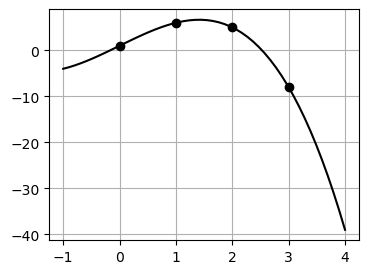

In [2]:
xi = np.array([0.,1.,2.,3.])
yi = np.array([1.,6.,5.,-8.])

x = np.linspace(-1,4)
y = 1+6*x-x**3

plt.plot(xi,yi,'o',x,y,color='black')
plt.grid()

Computacionalmente, podemos resolver esse exemplo como é mostrado a seguir, utilizando as operações vetorizadas da biblioteca `numpy` para montar a matriz do sistema e a função `solve` do módulo `linalg` para resolver, assim obtemos facilmente os coeficientes do polinômio interpolador. Também podemos usar a conveniente função `polyval` para avaliar o valores do polinômio em um conjunto de valores de $x$. Faremos isso para verificar se correspondem aos valores da função, como é esperado, ou seja, se $P(x_i)=y_i$, $i=0,1,2,3$. 





In [3]:
A = np.array([xi**0,xi**1,xi**2,xi**3]).T
#ou  A = np.polynomial.polynomial.polyvander(xi,3)
ai = np.linalg.solve(A,yi)
coeffs = np.flipud(ai) # reverte a ordem

print ("Coeficientes:", np.round(ai,2))
# Testando o polinômio nos pontos xi
print ("P(xi):", np.polyval(coeffs,xi))

Coeficientes: [ 1.  6.  0. -1.]
P(xi): [ 1.  6.  5. -8.]


Como é possível notar, com poucas linhas de código, utilizando as convenientes funções disponíveis na biblioteca NumPy, é possível obter o polinômio que interpola os pontos dados. Podemos também verificar que os numéricos do polinômio em cada um dos pontos coincidem com os valores da função, ou seja, $f(x_i)$, $i=0,1,2,3$.

Embora sempre seja possível obter o polinômio interpolador de grau  que passa por um conjunto de  pontos distintos resolvendo um sistema linear, essa pode não ser a maneira mais eficiente de fazer isso. A seguir serão apresentadas duas fórmulas bem conhecidas para interpolação polinomial que requerem menos esforço computacional, as fórmula de Lagrange e de Newton. A primeira requer um número maior de operações aritméticas básicas mas ainda assim pode ser mais vantajosa quando várias funções precisam ser interpoladas no mesmo conjunto de pontos. 
    

### 11.2. Fórmula Interpolatória de Lagrange

Seja $f(x)$ definida em $x_0, x_1,...,x_n$, $(n+1)$ pontos distintos de um intervalo $[a,b]$ e $y_i=f(x_i)$, $i=0,1,...,n$, então o polinômio interpolador de Lagrange é dado por 

$$P(x)=\sum_{k=0}^{n} y_k L_k(x) $$

com

$$ L_k(x) = \prod_{j=0 e j\neq k}^{n} \frac{(x-x_j)}{(x_k-x_j)}$$

**Exemplo 11.3:** Considere a função $f(x)$ definida nos pontos $\{(0.0, 1.9), (1.5, 2.5), (2.0, 0.9)\}$. Determine o polinômio interpolador, usando a fórmula de Lagrange, e estime $f(0.9)$.

*Solução:* Queremos o polinômio na forma $P(x) = y_0 L_0(x) + y_1 L_1(x) + y_2 L_2(x)$. Então, obtemos os $L_k(x)$ fazendo

$L_0 = \frac{(x-x_1)(x-x_2)}{(x_0-x_1)(x_0-x_2)} = \frac{(x-1,5)(x-2,0)}{(0,0-1,5)(0,0-2,0)} = 
\frac{x^2 - 3,5x + 3,0}{3,0}$

$L_1 = \frac{(x-x_0)(x-x_2)}{(x_1-x_0)(x_1-x_2)}=\frac{(x-0,0)(x-2,0)}{(1,5-0,0)(1,5-2,0)}=\frac{x^2-1,5x}{1,0}$

$L_2 = \frac{(x-x_0)(x-x_1)}{(x_2-x_0)(x_2-x_1)}=\frac{(x-0,0)(x-1,5)}{(2,0-0,0)(2,0-1,5)}=\frac{x^2-1,5x}{1,0}$

Assim,
$P(x)=1,9 \left(\frac{x^2 - 3,5x + 3,0}{3,0}\right) + 2,5 \left( \frac{x^2-1,5x}{1,0}\right) + 0.9 \left( \frac{x^2-1,5x}{1,0}\right) = -1,8x^2 - 3,1x + 1,9$

Portanto, tem-se

$P(0.9) = -1,8(0,9)^2 - 3,1(0,9) + 1,9 = 3,2320$.

O script Python abaixo plota o gráfico do polinômio obtido juntamente com os pontos tabelados.

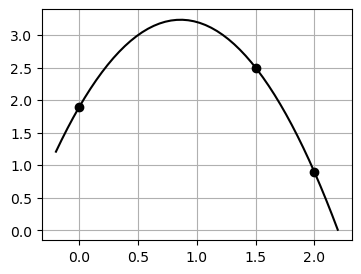

In [4]:
x = [0.0, 1.5, 2.0]
y = [1.9, 2.5, 0.9]

def P(x): 
    return  -1.8*x**2 + 3.1*x + 1.9

xi= np.linspace(-0.2, 2.2)
plt.plot(x, y, 'o', xi, P(xi),'-', 
         color='black')

plt.grid()
plt.show()

**Exemplo 11.4: (usando computação simbólica)** Vamos agora repetor o exemplo 11.3 mas usando a biblioteca SymPy.

In [5]:
import sympy as sp
x = sp.symbols("x", real=True)

xi = [0.0, 1.5, 2.0]
yi = [1.9, 2.5, 0.9]

Cálculo do $L_0$ (`nsimplify` força a representação fracionária)

In [6]:
L0 = sp.nsimplify(((x-xi[1])*(x-xi[2]))/((xi[0]-xi[1])*(xi[0]-xi[2])))
sp.expand(L0)

x**2/3 - 7*x/6 + 1

Cálculo do $L_1$

In [7]:
L1 = sp.nsimplify(((x-xi[0])*(x-xi[2]))/((xi[1]-xi[0])*(xi[1]-xi[2])))
sp.expand(L1)

-4*x**2/3 + 8*x/3

Cálculo do $L_2$

In [8]:
L2 = sp.nsimplify(((x-xi[0])*(x-xi[1]))/((xi[2]-xi[0])*(xi[2]-xi[1])))
sp.expand(L2)

x**2 - 3*x/2

Cálculo de $P(x)$

In [9]:
P = sp.expand(yi[0]*L0 + yi[1]*L1 +yi[2]*L2)
P

-1.8*x**2 + 3.1*x + 1.9

In [10]:
P.subs(x, 0.9)

3.23200000000000

No código abaixo é mostrada uma função que calcula o valor numérico do polinômio interpolador usando a fórmula de Lagrange para um dado valor de $x$. Usando essa função vamos calcular o valor de $P(0.9)$ e, também, fazer um laço de repetição para calcular o calor do polinômio em um conjunto de pontos para construir o gráfico. Observe que, como é esperado, o gráfico é igual ao do polinômio que foi obtido analiticamente no exemplo 3.3.

**Exemplo 11.5:** Neste exemplo é mostrado uma função que calcula o valor do polinômio em um ponto pela fórmula de Lagrange. Pra testar, vamos novamente usar os dados do Exemplo 11.3.

In [11]:
# A função recebe os valores tabelados e o valor de x 
# para o qual queremos obter o valor numérico do polinômio

def calculaP_Lagrange(X,Y,x):
    valor = 0
    for k in range(len(X)):
        lk = 1.0
        for i in range(len(X)):
            if k != i:
                lk = lk*(x - X[i])/(X[k]-X[i])
        valor = valor + Y[k]*lk 
    return valor

In [12]:
xi = np.array([0.0, 1.5, 2.0])
yi = np.array([1.9, 2.5, 0.9])

In [13]:
# calculando P(0.9)
print ("P(",0.9,") =", calculaP_Lagrange(xi,yi, 0.9))

P( 0.9 ) = 3.232


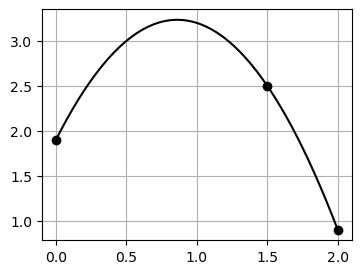

In [14]:
# Calculando para vários pontos e fazendo o gráfico

xp = np.linspace(xi[0], xi[-1])
yp = []
for x in xp:
    y = calculaP_Lagrange(xi, yi, x)
    yp.append(y)

plt.plot(xi, yi, 'o', xp, yp,'-',color='black')
plt.grid()
plt.show()

**Exemplo 11.6:** Considere a função $f(x)= \frac{0,2x^2sen(x)}{ln\left[(1+x)^2 \right]}$ definida em seis pontos igualmente espaçados tais que $x_0=0.5$ e $x_5=5.5$. Vamos usar a função do Exemplo 11.3 para plotar o gráfico do polinômio interpolador de Lagrage juntamente com o gráfico da função e os plontos utilizados.


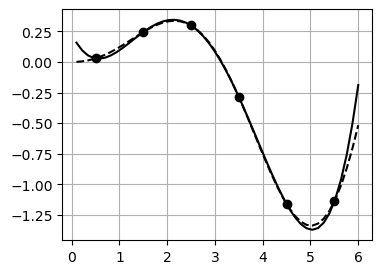

In [15]:
f = lambda x:(0.2*x**2*np.sin(x))/np.log((1 + x)**2)
xi = np.linspace(0.5,5.5,6)
yi = f(xi)

xp = np.linspace(0.1, 6)
yp = []
for x in xp:
    y = calculaP_Lagrange(xi, yi, x)
    yp.append(y)

plt.plot(xi, yi, 'o', 
         xp, yp,'-',
         xp,f(xp),'--',color='black')
plt.grid()
plt.show()

### 11.3 Fórmula interpolatória de Lagrange para pontos equidistantes

Se os pontos $x_0, ..., x_n$ forem igualmente espaçados, ou seja, se $x_{i+1}-x_i=h$ para $i=0, ..., n-1$, então é possível fazer uma mudança de variável e obter uma fórmula simplificada para o polinômio interpolador de Lagrange.
Fazemos 

$$ u = \frac{x-x_0}{h} $$
que é o mesmo que
$$ x = x_o +uh$$


Com essas mudanças, a fórmula de Lagrange fica 

$$P(u)=\sum_{k=0}^{n} y_k L_k(u) $$

com

$$ L_k(u) = \prod_{j=0 e j\neq k}^{n} \frac{(u-j)}{(k-j)}$$

Para avaliar o valor do polinômio de um determinado valor de $x$ precisamos obter o valor correspondente na variável $u$, fazendo, $ u = \frac{x-x_0}{h} $ e calcular $P(u)$.


**Exemplo 11.7:** Considere a função $f(x) = \cos(x)$. Obtenha uma aproximação para $f(0.3)$ usando um polinômio de grau 2 com $x_0 = 0.2$ e $h=0.2$.

In [16]:
def calculaP_Lagrange2(X,Y,u):
    valor = 0
    for k in range(len(X)):
        lk = 1.0
        for i in range(len(X)):
            if k != i:
                lk = lk*(u - i)/(k-i)
        valor = valor + Y[k]*lk 
    return valor

In [17]:
X = np.linspace(0.2, 0.6, 3)
Y = np.cos(X)

h = X[1]-X[0]
u = (0.3 - X[0])/h

print (calculaP_Lagrange2(X,Y,u))

0.9551537603289194


In [18]:
import sympy

In [19]:
# definindo os símbolos
x, u = sympy.symbols("x, u", real=True)
Xi = [0.1, 0.3, 0.5, 0.7]
Yi = [1.2500,1.5678,3.6789,8.8900]

def calculaL(k, Xi):
    Lk = 1
    Lk_num = 1
    Lk_den = 1
    for i, xi in enumerate(Xi):
        xk = Xi[k]
        if i!=k:
            Lk_num = Lk_num * (x-xi)
            Lk_den = Lk_den * (xk-xi)
    #print ('(',expand(Lk_num),')','/',Lk_den)
    return sympy.expand(Lk_num)/Lk_den

def calculaP(Xi):
    P = 0
    for k in range(len(Xi)):
        Lk = calculaL(k, Xi)
        print ('L',k,'=',Lk)
        P = P + Yi[k]*Lk
    return P

In [20]:
P = calculaP(Xi)

L 0 = -20.8333333333333*x**3 + 31.25*x**2 - 14.7916666666667*x + 2.1875
L 1 = 62.5*x**3 - 81.25*x**2 + 29.375*x - 2.1875
L 2 = -62.5*x**3 + 68.75*x**2 - 19.375*x + 1.3125
L 3 = 20.8333333333333*x**3 - 18.75*x**2 + 4.79166666666667*x - 0.3125


In [21]:
sympy.pprint(P)

                  3                     2                                  
27.2229166666668⋅x  - 2.08437500000008⋅x  - 1.11622916666663⋅x + 1.35524375


In [22]:
P3= lambda x: 27.2229*x**3 -2.0844*x**2 -1.1162*x +1.3552

In [23]:
x_plot = np.linspace(Xi[0], Xi[-1])
y_plot = P3(x_plot)

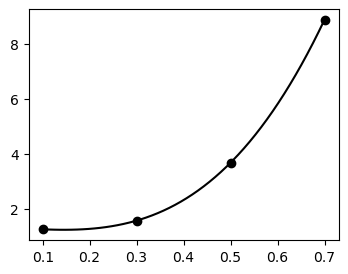

In [24]:
plt.plot(Xi,Yi,'o',x_plot,y_plot,'-',color='black')
plt.show()

A seguir é apresentado um exemplo de como obter as diferenças divididas para um conjunto de 5 pontos distintos da função $f(x)=1/x$. 

**Exemplo 5:** Considere os pontos 
\begin{array}{cccccc}
\hline
i   &0     &1    &2     &3     &4     \\ \hline
x_i &1     &2    &4     &5     &8     \\ 
f(x_i) &1.00  &0.50 &0.25  &0.20  &0.125 \\ \hline
\end{array}

Diferenças divididas de ordem 0:

$f[x_0]=f(x_0)=f(1)=1.00$\
$f[x_1]=f(x_1)=f(2)=0.50$\
$f[x_2]=f(x_2)=f(4)=0.25$\
$f[x_3]=f(x_3)=f(5)=0.20$\
$f[x_4]=f(x_4)=f(8)=0.125$

Diferenças divididas de ordem 1:

$f[x_0,x_1]=\frac{f[x_1]-f[x_0]}{x_1-x_0}=\frac{0.5-1}{2-1}=-0.5$\
$f[x_1,x_2]=\frac{f[x_2]-f[x_1]}{x_2-x_1}=\frac{0.25-0.5}{4-2}=-0.125$\
$f[x_2,x_3]=\frac{f[x_3]-f[x_2]}{x_3-x_2}=\frac{0.2-0.25}{5-4}=-0.05$\
$f[x_3,x_4]=\frac{f[x_4]-f[x_3]}{x_4-x_3}=\frac{0.125-0.2}{8-5}=-0.025$

Diferenças divididas de ordem 2:

$f[x_0,x_1,x_2]=\frac{f[x_1,x_2]-f[x_0,x_1]}{x_2-x_0}=\frac{-0.125-(-0.5)}{4-1}=0.125$\
$f[x_1,x_2,x_3]=\frac{f[x_2,x_3]-f[x_1,x_2]}{x_3-x_1}=\frac{-0.05-(-0.125)}{5-2}=0.025$\
$f[x_2,x_3,x_4]=\frac{f[x_3,x_4]-f[x_2,x_3]}{x_4-x_2}=\frac{-0.025-(-0.05)}{8-4}=0.00625$

Diferenças divididas de ordem 3:

$f[x_0,x_1,x_2,x_3]=\frac{f[x_1,x_2,x_3]-f[x_0,x_1,x_2]}{x_3-x_0}=\frac{0.025-0.125}{5-1}=-0.025$\
$f[x_1,x_2,x_3,x_4]=\frac{f[x_2,x_3,x_4]-f[x_1,x_2,x_3]}{x_4-x_1}=\frac{0.00625-0.025}{5-2}=-0.003125$

Diferenças divididas de ordem 4:

$f[x_0,x_1,x_2,x_3,x_4]=\frac{f[x_1,x_2,x_3,x_4]-f[x_0,x_1,x_2,x_3]}{x_4-x_0}=\frac{-0.003125-(-0.025)}{8-1}=0.003125$

Para facilitar o cálculo dessas diferencas divididas, é conveniente construir uma tabela em que cada coluna, a partir da terceira, é obtida usando as diferencas entre elementos consecutivos da coluna anterior e valores correspondentes da coluna de $x_i$. Para o exemplo anterior a tebela ficaria como é mostrado a seguir:


\begin{eqnarray*}
x_i& & &f[x_i]&  &f[x_i,x_{i+1}]&  &f[x_i,\dots,x_{i+2}]&  &f[x_i,\dots,x_{i+3}]&  &f[x_i,\dots,x_{i+4}]\\ \hline
1&  & &1&      &-0.5&    &0.125&   &-0.025&  &0.003125\\
2&  & &0.5&    &-0.125&  &0.025&   &-0.003125\\
4&  & &0.25&   &-0.05&   &0.00625\\
5&  & & 0.2&   &-0.025\\
8&  & &0.125
\end{eqnarray*}


Observe que as colunas da tabela acima podem ser calculadas de forma bastante prática usando operações vetoriais entre `numpy.arrays`, por exemplo as diferencas divididas de ordem 1 podem ser obtidas fazendo `(f[1:]-f[0:-1])/(x[1:]-x[0:-1])` sendo `x` e `f` _arrays_ contendo os dados de $x_i$ e $f(x_i)$ conforme é mostrado a seguir:

In [25]:
x = np.array([1.,2.,4.,5.,8.])
f = 1/x
(f[1:]-f[0:-1])/(x[1:]-x[0:-1])

array([-0.5  , -0.125, -0.05 , -0.025])

fazendo um laço de repetição para as linhas seguintes podemos obter a tabela de diferenças divididas como é mostrado abaixo:

In [26]:
n = len(x)
for i in range(1,n+1):
    print (f)
    f= (f[1:]-f[0:-1])/(x[i:n]-x[0:n-i])

[1.    0.5   0.25  0.2   0.125]
[-0.5   -0.125 -0.05  -0.025]
[0.125   0.025   0.00625]
[-0.025    -0.003125]
[0.003125]


Por fim, como precisamos apenas do primeiro elemento de cada linha acima, bastaria armazenar os resultados em um único `array`como é mostrado abaixo  

In [27]:
f = 1/x
for i in range(1,n):
    f[i:n] = (f[i:n] - f[i-1])/(x[i:n] - x[i-1])
print (f)

[ 1.       -0.5       0.125    -0.025     0.003125]


Uma vez calculadas as diferenças divididas, usa-se o seguinte método recursivo para avaliar o polinômio em um determinado valor de $x$

$P_0(x) = f[x_0,\dots,x_n]$

$P_1(x) = f[x_0,\dots,x_{n-1}]+ (x-x_{n-1})P_0(x)$

$P_2(x) = f[x_0,\dots,x_{n-2}]+ (x-x_{n-2})P_1(x)$

$\vdots$

$P_n(x) = f[x_0]+ (x-x_0)P_n(x)$


#### Exemplo 6

Seja a função $f(x)=e^xcos(x)\sqrt{x}$ tabelada  nos pontos $x_0=0.0$, $x_1=1.0$, $x_2=2.3$, $x_3=2.5$ e $x_4=4.0$. Vamos usar a fórmula de interpolatória de Newton para obter o gráfico do polinômio que interpola esses pontos calculando o valor numérico do poliômio em conjunto discreto de pontos. Também vamos obter uma forma analítica para esse polinônio usando Python. 

In [28]:
# Definindo a lista de pontos a serem interpolados
func = lambda x: np.exp(x)*np.cos(x)*np.sqrt(x)
xi = np.array([ 0, 1.0, 2.3, 3.5, 4.0])
yi = func(xi)

In [29]:
# uma função para calcular as diferenças divididas
def difdiv(x,y):
    m = len(x)
    dd = y.copy()
    for k in range(1,m):
        dd[k:m]=(dd[k:m]-dd[k-1])/(x[k:m]-x[k-1])
    return dd

In [30]:
f = difdiv(xi,yi)
print(f)

[ 0.          1.46869394 -4.50049655 -2.26454299  2.25023479]


In [31]:
def calculaP(f,xi,x):
    n = len(xi) - 1
    p = f[n]
    for i in range(1,n+1):
        p = f[n-i] + (x -xi[n-i])*p
    return p

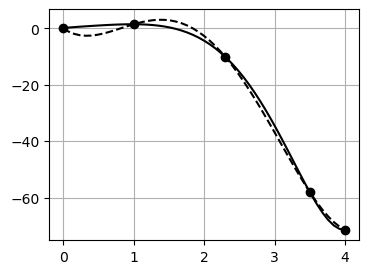

In [32]:
# Cria a lista de pontos para o plot
xp = np.linspace(0, 4, num=51) 
yp = []
for x in xp: 
    yp.append(calculaP(f,xi,x))

# Plota
plt.plot(xi, yi, 'o', 
         xp, func(xp),'-', 
         xp, yp,'--',color='k')
plt.grid()
plt.show()

In [33]:
import sympy
x = sympy.symbols("x", real=True)

n = len(xi) - 1
p = f[n]
for i in range(1,n+1):
    p = f[n-i] + (x -xi[n-i])*p
sympy.expand(p)


2.25023478908295*x**4 - 17.566139553712*x**3 + 34.1382471378265*x**2 - 17.3536484332815*x

#### Exemplo 6

Considere a função $f(x)=\frac{x}{(x+1)}$ tabelada  nos pontos $x_0=0.0$, $x_1=1.0$ e $x_2=2.0$. Determine o polinômio interpolador usando a fórmula de Newton e avalie $f(1.3)$. 

In [34]:
xi = np.array([0., 1.0, 2.0])
func = lambda x: np.divide(x, x + 1)
yi = func(xi)


In [35]:
f = difdiv(xi,yi)
print (f)

[ 0.          0.5        -0.16666667]


P(1.3) = 0.5850000000000001


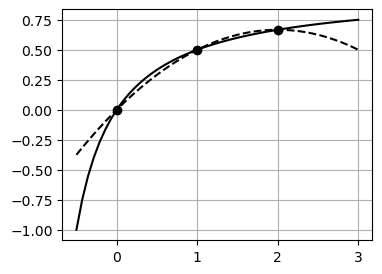

In [36]:
print ("P(1.3) =", calculaP(f,xi,1.3))

xp = np.linspace(-0.5, 3)
yp = []

for x in xp:
    yp.append(calculaP(f,xi,x))

plt.plot(xi, yi, "o", 
         xp, yp, "--",
         xp, func(xp),"-",
         color='black')
plt.grid()
plt.show()

A biblioteca SciPy para computação científica em Python possui diversos algoritmos para interpolação uni e multidimensional, incluindo _splines_, métodos de Lagrange e baseados em série de Taylor. Veja como fica fácil com o exemplo abaixo.

In [37]:
from scipy.interpolate import lagrange

a = lagrange(xi, yi)
print(a.coef)

[-0.16666667  0.66666667  0.        ]


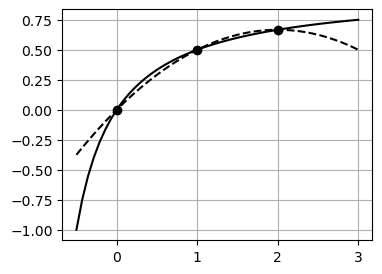

In [38]:
plt.plot(xi, yi, 'o', 
        xp, np.polyval(a,xp),'--',
        xp, func(xp),"-",
        color='black')
plt.grid()
plt.show()

 Para saber mais, pesquise sobre `scipy.interpolate` na _internet_.

### Exercícios

**1.** Encontre polinômios interpoladores para as funções 

(a) $ln(x+1)$, 

(b) $\sqrt{1+x}$ e 

(c) $e^{2x}cos(3x)$ 

no intervalo de $x_0=1$ até $x_n=3$ com $3$, $4$ e $5$ pontos escolhidos arbitrariamente no intervalo.

**2.** Dada a tabela a seguir de valores de uma função $f$,

x   | 0,15 | 0,17 | 0,19 | 0,21 | 0,23 | 0,25 | 0,27 | 0,29 | 0,31  | 
----|------|------|------|------|------|------|------|------|-------|
f(x)|0,176 |0,234 |0,278 |0,322 |0,361 |0,398 |0,431 |0,462 |0,491  | 

(a) Obtenha uma estimativa para $f(0,20)$ e para $f(0,22)$ utilizando interpolação polinomial. (b) Obtenha a expressão analítica do polinômio interpolador. Plote o gráfico. (c) Estime $f(0,20)$ e $f(0,22)$ utilizando uma polinomial de terceiro grau. Plote o gráfico e compare com o resultado do item anterior. 

**3.** Considere a função 
$$f(x)=\frac{3.21}{0.73 + 9.81x^2}$$

(a) Aproxime o valor de $f(1.78)$ usando um polinômio interpolador de grau 3 no intervalo [1, 2] e compare com o valor da função. Mostre o gráfico do polinômio e da função nesse intervalo. (b) Repita o item anterior, mas dessa vez utilize um polinômio de grau 10 no intervalo [-2,2] e comente o que você observou. (c)Pesquise e responda o que é "Fenômeno de Runge".

**4.** O concreto novo ganha resistência com o passar dos dias atingindo 99% de sua resistência máxima aos 28 dias. A tabela abaixo mostra os resultados de um ensaio de resistência à compressão simples (em MPa), obtidos em laboratório especializado, de três diferentes traços de concreto:
1. Dosagem padrão, sem a adição de agregado miúdo reciclado
2. Substituindo 20% de agregado miúdo natural por agregado miúdo reciclado
3. Substituindo 40% de agregado miúdo natural por agregado miúdo reciclado.

Dias |Traço 1 |Traço 2 |Traço 3 
-----|--------|--------|-------
3    |14,4025 |21,8450 |19,0045 
7    |27,4350 |31,2800 |26,7450 
14   |34,4900 |35,1600 |31,3000 
21   |34,3750 |38,1000 |34,1800 
28   |36,1650 |39,9800 |35,6550 


(a) Encontre o polinômio que interpola dos dados de cada um dos ensaios, faça o gráfico. (b) Estime quantos dias são necessários para que cada um dos concretos alcance 32 MPa. (c) Encontre a resistência de cada concreto após 16 dias. 

**5.** Durante três dias consecutivos foi tomada a temperatura (em $^\circ$C) numa região de uma
cidade, por quatro vezes no período das 6 às 12 horas. Determine, usando todos os dados
da tabela abaixo, a média das temperaturas dos três dias às 9 horas.

Hora |1º dia |2º dia |3ºdia| 
-----|-------|-------|-----|
6    |18.5   |17.2   |18.1 |
8    |20.3   |20.1   |21.4 |
10   |24.0   |25,1   |22.9 |
12   |28.2   |27.5   |23.7 |

